# 06b — memsearch agent-memory benchmark (WS6b)

**Feeds C9 (the break-even's right side), C10, all of C12, C1 and C15.**

Design: `results/code-retrieval.md`.
Verdicts are keyed to its **§8 PRE-REGISTERED INTERPRETATION**, which was
committed before any data existed.

This notebook does **analysis only** — it reads committed CSVs and writes
committed CSVs. It does not call an API and does not need Milvus. The run
itself is `scripts/code-retrieval/run_ws6b_arms.py`.

Runtime: seconds. RAM: trivial.

**Requires:** `results/ws6b/{runs,probes,corpus_stats,pricing,index_cost,skip_rate}.csv`


In [1]:
# ---- setup ------------------------------------------------------------------
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from benchlib import config, manifest
from benchlib.code_retrieval import memory as ws6b

OUT = config.ws6b_dir()
runs = pd.read_csv(OUT / "runs.csv")
probes = pd.read_csv(OUT / "probes.csv")
stats = pd.read_csv(OUT / "corpus_stats.csv").set_index("size")
index_cost = pd.read_csv(OUT / "index_cost.csv")
skip = pd.read_csv(OUT / "skip_rate.csv")
gate = pd.read_csv(OUT / "parametric_gate.csv")

print(f"{len(runs)} runs, {len(probes)} probes")
print(runs.groupby(["arm"]).size())

125 runs, 38 probes
arm
memsearch@l       38
memsearch@m       12
memsearch@s       12
replay@l           1
replay@m          12
replay@s          12
replay_trunc@l    38
dtype: int64


## Assertion cell — the run must be complete and clean

The only permitted error is the single deliberate `window_exceeded` at L
(spec §8.4). Anything else means a cell did not finish and no number below
is trustworthy.

In [2]:
# ---- completeness gate ------------------------------------------------------
bad = runs[(runs.status != "ok") & (runs.status != "window_exceeded")]
assert bad.empty, f"unexpected statuses:\n{bad[['qid','arm','status']]}"

cliff = runs[runs.status == "window_exceeded"]
assert len(cliff) == 1, f"expected exactly one window_exceeded row, got {len(cliff)}"

ok = runs[runs.status == "ok"].copy()
expected = {"memsearch@s": 12, "replay@s": 12, "memsearch@m": 12,
            "replay@m": 12, "memsearch@l": 38, "replay_trunc@l": 38}
got = ok.groupby("arm").size().to_dict()
assert got == expected, f"cell sizes wrong: {got} != {expected}"

# Spec 7.1: prompt_tokens must include the cache fields, or replay looks free.
worst = ok.loc[ok.prompt_tokens.idxmax()]
assert worst.prompt_tokens > worst.input_tokens * 10, (
    "prompt_tokens is not picking up cache_read/cache_creation")
print("complete and clean.")
print(f"window cliff: {cliff.iloc[0].qid} — {str(cliff.iloc[0].api_error)[:200]}")

complete and clean.
window cliff: f00 — BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'prompt is too long: 1221932 tokens > 1000000 maximum'}, 'request_id': 'req_011CeAVeYJQ2Toxau


## Per-size summaries

One CSV per size. `cost_per_correct_usd` and `stale_rate` were defined in
spec §7.2 **before any data existed**, so neither can be a post-hoc rescue.

In [3]:
# ---- summaries --------------------------------------------------------------
summaries = {}
for size in ("s", "m", "l"):
    sub = ok[ok["size"] == size]
    rows = (sub.drop(columns=["arm"])
           .rename(columns={"arm_base": "arm"}).to_dict("records"))
    s = pd.DataFrame(ws6b.summarise(rows)).T.reset_index(drop=True)
    s.insert(1, "corpus_tokens", int(stats.loc[size, "count_tokens"]))
    summaries[size] = s
    s.to_csv(OUT / f"summary_{size}.csv", index=False)
    manifest.record(OUT / f"summary_{size}.csv")
    print(f"\n=== {size.upper()}  ({int(stats.loc[size,'count_tokens']):,} tokens) ===")
    print(s.to_string(index=False))


=== S  (98,134 tokens) ===
      arm  corpus_tokens  n judge_accuracy median_prompt_tokens total_billed_usd total_list_usd median_billed_usd cost_per_correct_usd stale_rate stale_mentioned_rate turn_cap_rate
memsearch          98134 12            1.0               4554.0         0.137718       0.137718          0.010043             0.011477       None                 None           0.0
   replay          98134 12            1.0              98244.0         0.239602       2.361286          0.019941             0.019967       None                 None           0.0

=== M  (392,116 tokens) ===
      arm  corpus_tokens  n judge_accuracy median_prompt_tokens total_billed_usd total_list_usd median_billed_usd cost_per_correct_usd stale_rate stale_mentioned_rate turn_cap_rate
memsearch         392116 12            1.0               4635.5          0.14936        0.14936          0.010201             0.012447       None                 None           0.0
   replay         392116 12           

## C12 — the curve (spec §8.2)

`scaling` probe set only: the **same 12 questions** at all three sizes, so
corpus size is the only variable.

Pre-registered guard: replay's token growth is linear in history size **by
construction**. It is arithmetic, not a discovery, and is not the finding.
The reportable quantities are the crossover bracket, arm (a)'s slope,
accuracy by depth band, and the window cliff.

    arm_base size  median_prompt_tokens  median_billed judge_accuracy  corpus_tokens
   memsearch    s                4554.0       0.010043            1.0          98134
   memsearch    m                4635.5       0.010201            1.0         392116
   memsearch    l               10593.0       0.023181            1.0        1221906
      replay    s               98244.0       0.019941            1.0          98134
      replay    m              392189.0       0.078895            1.0         392116
replay_trunc    l              959269.0       0.194048            0.0        1221906


'50ea16cf637d397e45682482fdf5cf045e384aafcdc4dcc7e8fcfd78b89c1b5f'

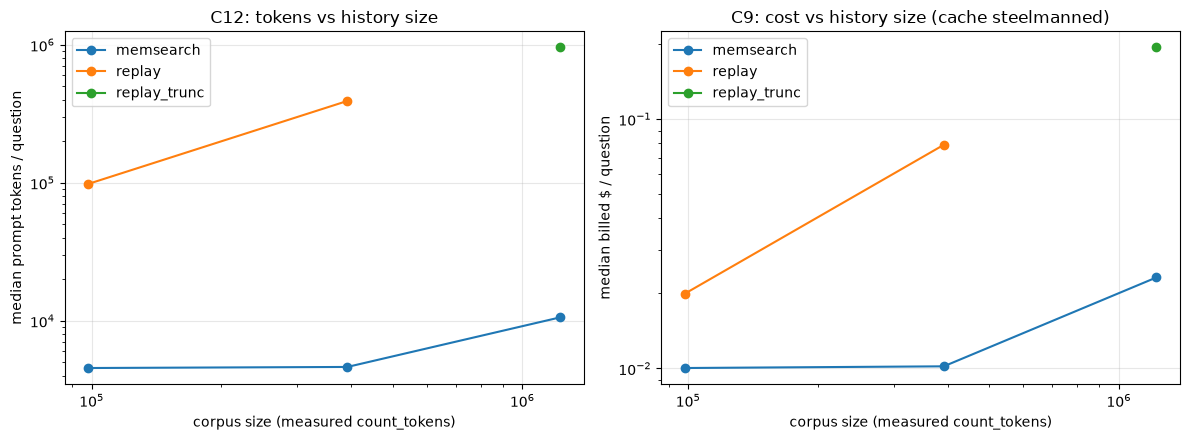

In [4]:
# ---- C12 curve --------------------------------------------------------------
sc = ok[ok.probe_set == "scaling"]
curve = (sc.groupby(["arm_base", "size"])
           .agg(median_prompt_tokens=("prompt_tokens", "median"),
                median_billed=("cost_billed_usd", "median"),
                judge_accuracy=("judge_correct", "mean"))
           .reset_index())
curve["corpus_tokens"] = curve["size"].map(stats["count_tokens"])
curve = curve.sort_values(["arm_base", "corpus_tokens"])
print(curve.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for arm, g in curve.groupby("arm_base"):
    ax[0].plot(g.corpus_tokens, g.median_prompt_tokens, "o-", label=arm)
    ax[1].plot(g.corpus_tokens, g.median_billed, "o-", label=arm)
for a, ylab, title in ((ax[0], "median prompt tokens / question",
                        "C12: tokens vs history size"),
                       (ax[1], "median billed $ / question",
                        "C9: cost vs history size (cache steelmanned)")):
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel("corpus size (measured count_tokens)"); a.set_ylabel(ylab)
    a.set_title(title); a.grid(alpha=.3); a.legend()
fig.tight_layout()
fig.savefig(OUT / "chart_cost_vs_history.png", dpi=150)
manifest.record(OUT / "chart_cost_vs_history.png")

## C9 — the crossover, reported as a bracket (spec §8.1)

Three sizes do not license a fitted line. If the cheaper arm changes between
two measured sizes, the crossover is reported as **bracketed between them**,
never interpolated to a point.

In [5]:
# ---- crossover bracket ------------------------------------------------------
piv = curve.pivot(index="size", columns="arm_base", values="median_billed")
piv["corpus_tokens"] = stats["count_tokens"]
piv = piv.sort_values("corpus_tokens")
piv["cheaper"] = piv[["memsearch", "replay", "replay_trunc"]].idxmin(axis=1)
print(piv.to_string())

order = list(piv.index)
flips = [(order[i], order[i + 1]) for i in range(len(order) - 1)
         if piv.cheaper[order[i]] != piv.cheaper[order[i + 1]]]
if flips:
    for a, b in flips:
        print(f"\nCROSSOVER BRACKETED between {a.upper()} "
              f"({int(piv.corpus_tokens[a]):,} tok, cheaper={piv.cheaper[a]}) "
              f"and {b.upper()} ({int(piv.corpus_tokens[b]):,} tok, "
              f"cheaper={piv.cheaper[b]}). NOT interpolated (spec 8.1).")
else:
    winner = piv.cheaper.iloc[0]
    # Naming the branch correctly matters more than the number. B1 is
    # "memsearch cheaper AND not materially less accurate"; B2 is the
    # OPPOSITE -- cached replay winning at every size. An earlier version of
    # this cell printed B2 for a memsearch win, which would have put a
    # falsified branch label into the committed results.
    branch = "B1" if winner == "memsearch" else "B2"
    print(f"\nNo crossover in the tested range: {winner} is cheaper at every "
          f"tested size, so the crossover lies BELOW S "
          f"({int(piv.corpus_tokens.iloc[0]):,} tokens) and is not bracketed "
          f"by this experiment. Spec 8.1 branch {branch}.")

arm_base  memsearch    replay  replay_trunc  corpus_tokens    cheaper
size                                                                 
s          0.010043  0.019941           NaN          98134  memsearch
m          0.010201  0.078895           NaN         392116  memsearch
l          0.023181       NaN      0.194048        1221906  memsearch

No crossover in the tested range: memsearch is cheaper at every tested size, so the crossover lies BELOW S (98,134 tokens) and is not bracketed by this experiment. Spec 8.1 branch B1.


## Accuracy by depth, and the window boundary (spec §8.4, §4.2)

The `depth` set at L. `replay_trunc` retains the most recent `fit_fraction`
of the history, so the shallow band sits outside its window and the deeper
bands inside. The boundary is therefore **measured across three bands**
rather than assumed.

    arm_base  band judge_accuracy  n in_window
   memsearch   0.1            1.0  6     False
   memsearch   0.5            1.0  6      True
   memsearch   0.9            1.0  6      True
replay_trunc   0.1            0.0  6     False
replay_trunc   0.5       0.833333  6      True
replay_trunc   0.9       0.833333  6      True


'd218bd03ddab7514439dc603e246d3d7156a3e8b355fc48ee6435ebdfc9fa952'

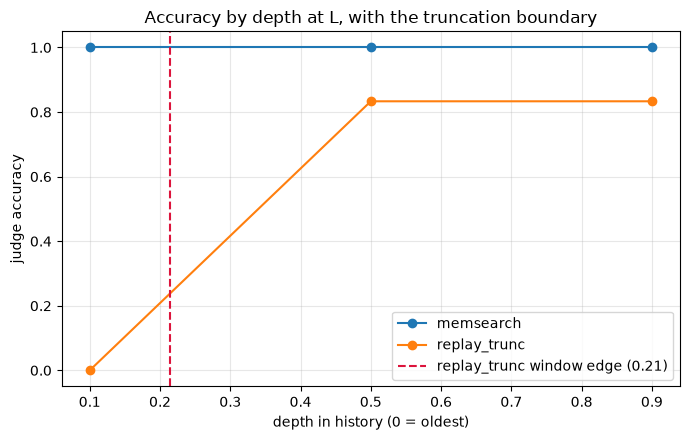

In [6]:
# ---- depth x window ---------------------------------------------------------
dep = ok[(ok.probe_set == "depth") & (ok["size"] == "l")].copy()
dep["band"] = dep.depth_l.round(1)
tab = (dep.groupby(["arm_base", "band"])
          .agg(judge_accuracy=("judge_correct", "mean"),
               n=("judge_correct", "size"),
               in_window=("fact_in_window", "first"))
          .reset_index())
print(tab.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
for arm, g in tab.groupby("arm_base"):
    ax.plot(g.band, g.judge_accuracy, "o-", label=arm)
fit_l = float(stats.loc["l", "fit_fraction"])
ax.axvline(1 - fit_l, ls="--", c="crimson",
           label=f"replay_trunc window edge ({1-fit_l:.2f})")
ax.set_xlabel("depth in history (0 = oldest)"); ax.set_ylabel("judge accuracy")
ax.set_ylim(-0.05, 1.05); ax.grid(alpha=.3); ax.legend()
ax.set_title("Accuracy by depth at L, with the truncation boundary")
fig.tight_layout()
fig.savefig(OUT / "chart_accuracy_by_depth.png", dpi=150)
manifest.record(OUT / "chart_accuracy_by_depth.png")

## Superseded facts — recency, not visibility (spec §4.3)

`original_in_window` is shown so a reader can verify the §4.3 guarantee held
in the published data: both statements of every pair were visible to both
arms, so `stale_rate` measures reasoning rather than what an arm could not
see.

In [7]:
# ---- stale rate -------------------------------------------------------------
sup = ok[ok.probe_set == "superseded"].copy()
sup_probes = probes[probes.probe_set == "superseded"]
assert (sup_probes.original_in_window == True).all(), (
    "a superseded original fell outside the truncation window — stale_rate "
    "would measure visibility, not recency (spec 4.3)")
print("4.3 guarantee holds: all superseded originals in-window.\n")
sup["stale_as_answer"] = sup.stale & ~sup.judge_correct
print(sup.groupby("arm_base")
        .agg(n=("stale", "size"), judge_accuracy=("judge_correct", "mean"),
             stale_rate=("stale_as_answer", "mean"),
             stale_mentioned_rate=("stale", "mean")).to_string())
print("\nstale_rate is JUDGE-GATED: committed to the superseded value, not "
      "merely mentioning it.\nA substring rate would score 'we changed it "
      "from 3319 to 8123' as a recency failure.")

4.3 guarantee holds: all superseded originals in-window.

              n judge_accuracy  stale_rate stale_mentioned_rate
arm_base                                                       
memsearch     8            1.0         0.0                  1.0
replay_trunc  8            1.0         0.0                  1.0

stale_rate is JUDGE-GATED: committed to the superseded value, not merely mentioning it.
A substring rate would score 'we changed it from 3319 to 8123' as a recency failure.


## Cost-model inputs for WS5, and the gate

In [8]:
# ---- WS5 inputs -------------------------------------------------------------
print("=== parametric gate (spec 5.5) ===")
g = gate.drop_duplicates("attempt")[["attempt", "generator_git_sha",
                                     "accuracy", "verdict"]]
print(g.to_string(index=False))

print("\n=== one-time index cost (derived, cl100k x list rate) ===")
print(index_cost[["size", "files_indexed", "milvus_count", "wall_clock_s",
                  "embed_tokens_cl100k", "embed_cost_usd"]].to_string(index=False))

print("\n=== incremental sync (WS5 churn arm) ===")
print(skip[["variant", "chunks_total", "chunks_reembedded", "skip_rate",
            "wall_clock_s", "embed_cost_usd"]].to_string(index=False))

print("\n=== cached vs uncached, the C9 gap ===")
gap = (ok.groupby("arm_base")
         .agg(billed=("cost_billed_usd", "sum"), listed=("cost_list_usd", "sum")))
gap["saving"] = 1 - gap.billed / gap.listed
print(gap.to_string())

print(f"\nTOTAL BILLED (agent only): ${ok.cost_billed_usd.sum():.4f}")

=== parametric gate (spec 5.5) ===
 attempt generator_git_sha  accuracy verdict
       1      17463a16a4da       0.0    pass

=== one-time index cost (derived, cl100k x list rate) ===
size  files_indexed  milvus_count  wall_clock_s  embed_tokens_cl100k  embed_cost_usd
   s             11           236          13.3                49984        0.001000
   m             48           936          44.3               201608        0.004032
   l            145          2906         126.5               630055        0.012601

=== incremental sync (WS5 churn arm) ===
    variant  chunks_total  chunks_reembedded  skip_rate  wall_clock_s  embed_cost_usd
   new_file          2907                  1   0.999656           1.8        0.000004
tail_append          2907                  1   0.999656           2.0        0.000004
   mid_edit          2906                  5   0.998279           2.3        0.000022

=== cached vs uncached, the C9 gap ===
                 billed     listed    saving
arm_b

## What this settles for C9 — and what it does not


In [9]:
# ---- what this does and does NOT settle for C9 -------------------------------
per_q = piv.loc["l"]
saving = per_q["replay_trunc"] - per_q["memsearch"]
build = float(index_cost.set_index("size").loc["l", "embed_cost_usd"])
print(f"L: memsearch ${per_q['memsearch']:.5f}/q vs replay_trunc "
      f"${per_q['replay_trunc']:.5f}/q -> saving ${saving:.5f}/q")
print(f"one-time index build (embedding only): ${build:.5f}")
print(f"queries to repay the BUILD alone: {build / saving:.2f}")
print("""
READ THIS NEXT TO THAT NUMBER. It is not the C9 break-even.

  * It amortises the EMBEDDING cost only. It excludes the vector store's
    running cost entirely -- this benchmark ran against a local Milvus that
    costs nothing per month. A hosted index has a monthly bill that does not
    appear anywhere above, and for a low query volume that bill, not the
    embedding, is what break-even is actually about.
  * It therefore says the index repays its BUILD almost immediately, which is
    a much weaker claim than "the index is worth running".
  * WS5 owns the real break-even: this workstream contributes the measured
    per-query token and cost deltas that feed it, and nothing more.

Reporting 'break-even after 0.07 queries' as the C9 headline would be the
most attackable number in the talk.""")

L: memsearch $0.02318/q vs replay_trunc $0.19405/q -> saving $0.17087/q
one-time index build (embedding only): $0.01260
queries to repay the BUILD alone: 0.07

READ THIS NEXT TO THAT NUMBER. It is not the C9 break-even.

  * It amortises the EMBEDDING cost only. It excludes the vector store's
    running cost entirely -- this benchmark ran against a local Milvus that
    costs nothing per month. A hosted index has a monthly bill that does not
    appear anywhere above, and for a low query volume that bill, not the
    embedding, is what break-even is actually about.
  * It therefore says the index repays its BUILD almost immediately, which is
    a much weaker claim than "the index is worth running".
  * WS5 owns the real break-even: this workstream contributes the measured
    per-query token and cost deltas that feed it, and nothing more.

Reporting 'break-even after 0.07 queries' as the C9 headline would be the
most attackable number in the talk.
